# Utilizing Rule-Based Semantic Extraction and Text Parsing to Automate Scoring Cards in *Magic: The Gathering*
### IMT 575 - Spring 2026
Samuel Lee, Sitong Liu, Zach Greenman

In [1]:
import pandas as pd
import numpy as np

from mtg_parser.utils.paths import RAW_DIR, PROCESSED_DIR
from mtg_parser.data.extract_creatures import build_creatures_dataset
from mtg_parser.data.build_dataset import save_cleaned_dataset

%load_ext autoreload
%autoreload 2

Preprocessing stuff for our dataset

In [2]:
# Build creatures dataset from default-cards
build_creatures_dataset()

# Save the cleaned dataset
save_cleaned_dataset()

[pipeline] Default-cards dataset already exists.
[pipeline] Creatures dataset already exists.
[cleaning] Missing oracle_id rows: 0
[cleaning] Duplicate values in rows: 0
[builder] Saved combined_points_cleaned.csv to /data/processed/


In [3]:
from mtg_parser.utils.paths import PROCESSED_DIR

cards_df = pd.read_csv(PROCESSED_DIR / 'combined_points_cleaned.csv')
cards_df["oracle_text"] = cards_df["oracle_text"].fillna("")
cards_df

,oracle_id,name,set,set_name,released_at,year,cmc,power,toughness,power_numeric,toughness_numeric,keywords,oracle_text,color_identity,rarity,points
0,4c81cfb7-8765-4e28-ae33-4287fa9a86cc,Benalish Hero,lea,Limited Edition Alpha,1993-08-05,1993,1.0,1,1,1.0,1.0,['Banding'],"Banding (Any creatures with banding, and up to...",['W'],common,3
1,218d9277-c179-4de3-9c7f-79b5a6d4fa38,Merfolk of the Pearl Trident,lea,Limited Edition Alpha,1993-08-05,1993,1.0,1,1,1.0,1.0,[],,['U'],common,2
2,10bc98b0-3fdc-46d1-8d3b-6d160e9dd62f,Goblin Balloon Brigade,lea,Limited Edition Alpha,1993-08-05,1993,1.0,1,1,1.0,1.0,[],{R}: This creature gains flying until end of t...,['R'],uncommon,3
3,d3a0b660-358c-41bd-9cd2-41fbf3491b1a,Birds of Paradise,lea,Limited Edition Alpha,1993-08-05,1993,1.0,0,1,0.0,1.0,['Flying'],Flying\n{T}: Add one mana of any color.,['G'],rare,4
4,8b60fcfe-fb90-4a00-a708-25b59bfc9b5a,Will-o'-the-Wisp,lea,Limited Edition Alpha,1993-08-05,1993,1.0,0,1,0.0,1.0,['Flying'],Flying (This creature can't be blocked except ...,['B'],rare,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,2c75623c-59f4-4449-ab43-9d1225185ad9,Rottenmouth Viper,blb,Bloomburrow,2024-08-02,2024,6.0,6,6,6.0,6.0,[],"As an additional cost to cast this spell, you ...",['B'],mythic,16
853,29423a9a-31a6-4605-8b49-a75895038a3a,Wick's Patrol,blb,Bloomburrow,2024-08-02,2024,6.0,5,3,5.0,3.0,['Mill'],"When this creature enters, mill three cards. W...",['B'],uncommon,12
854,e9c6e4e6-0c3f-4048-93e6-161a1221ea36,"Byrke, Long Ear of the Law",blb,Bloomburrow,2024-08-02,2024,6.0,4,4,4.0,4.0,"['Vigilance', 'Double']","Vigilance\nWhen Byrke enters, put a +1/+1 coun...","['G', 'W']",mythic,13
855,3c345e24-1726-45ac-91ca-e348d1e7acfe,Eddymurk Crab,blb,Bloomburrow,2024-08-02,2024,7.0,5,5,5.0,5.0,['Flash'],Flash\nThis spell costs {1} less to cast for e...,['U'],uncommon,15


In [4]:
import mtg_parser.parsing.keyword_router as kr

test_df = cards_df.sample(n=10, random_state=42)

test_df = kr.parse_keywords_column(test_df)

test_df
print(type(test_df['keywords']))

<class 'pandas.core.series.Series'>


In [5]:
import mtg_parser.pipeline.orchestrator as orch

bundles = orch.extract_abilities(test_df)

bundles

[CardAbilityBundle(oracle_id='33f4fcd5-4eea-4146-a564-da5511a8ee0a', name='Thought Shucker', set='blb', set_name='Bloomburrow', released_at='2024-08-02', cmc=2.0, abilities=[Ability(type=<AbilityType.ACTIVATED: 'activated'>, raw='Threshold — {1}{U}: Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once.', effect='Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once.', condition=None, cost='Threshold — {1}{U}')]),
 CardAbilityBundle(oracle_id='b2b76070-f103-4f83-ad21-119e6352f2cd', name='Glowstone Recluse', set='iko', set_name='Ikoria: Lair of Behemoths', released_at='2020-04-24', cmc=3.0, abilities=[Ability(type=<AbilityType.TRIGGERED: 'triggered'>, raw='Whenever this creature mutates, put two +1/+1 counters on it.', effect='put two +1/+1 counters on it.', condition='Whenever this creature mutates', cost=None)]),
 CardAbilityBund

In [6]:
for bundle in bundles:
    print(bundle.abilities)

[Ability(type=<AbilityType.ACTIVATED: 'activated'>, raw='Threshold — {1}{U}: Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once.', effect='Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once.', condition=None, cost='Threshold — {1}{U}')]
[Ability(type=<AbilityType.TRIGGERED: 'triggered'>, raw='Whenever this creature mutates, put two +1/+1 counters on it.', effect='put two +1/+1 counters on it.', condition='Whenever this creature mutates', cost=None)]
[Ability(type=<AbilityType.ACTIVATED: 'activated'>, raw='{2}{R}, {T}: Destroy target nonbasic land.', effect='Destroy target nonbasic land.', condition=None, cost='{2}{R}, {T}')]
[Ability(type=<AbilityType.TRIGGERED: 'triggered'>, raw='Whenever this creature deals combat damage to a player, you may draw a card.', effect='you may draw a card.', condition='Whenever this creature de

In [7]:
import mtg_parser.features.keyword_features as kf

keyword_features = [kf.build_keyword_features(row) for _, row in test_df.iterrows()]

keyword_features

[KeywordFeatures(features={}),
 KeywordFeatures(features={'reach': 1, 'mutate': 1}),
 KeywordFeatures(features={'morph': 1}),
 KeywordFeatures(features={'morph': 1, 'trample': 1}),
 KeywordFeatures(features={}),
 KeywordFeatures(features={'vigilance': 1}),
 KeywordFeatures(features={'forage': 1, 'offspring': 1}),
 KeywordFeatures(features={}),
 KeywordFeatures(features={'cycling': 1}),
 KeywordFeatures(features={'flying': 1})]

In [8]:
import mtg_parser.features.card_features as cf

cards = []

for _, row in test_df.iterrows():
    card = cf.build_card_features(orch.build_card_ability_bundle(row), row)
    cards.append(card)

print(cards[0])

CardFeatures(abilities=[Ability(type=<AbilityType.ACTIVATED: 'activated'>, raw='Threshold — {1}{U}: Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once.', effect='Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once.', condition=None, cost='Threshold — {1}{U}')], keyword_features=KeywordFeatures(features={}), power=1.0, toughness=3.0)


In [9]:
import mtg_parser.scoring.ability_scorer as a_scorer

ability_scores = []

for card in cards:
    ability_score = a_scorer.get_ability_scores(card.abilities)
    ability_scores.append(ability_score)

for i, ability_score_list in enumerate(ability_scores):
    print(f"\nCARD {i}")

    for a in ability_score_list:
        print(a.ability.raw, "->", a.score)

    print("TOTAL:", sum(a.score for a in ability_score_list))


CARD 0
Threshold — {1}{U}: Put a +1/+1 counter on this creature and draw a card. Activate only if there are seven or more cards in your graveyard and only once. -> 3
TOTAL: 3

CARD 1
Whenever this creature mutates, put two +1/+1 counters on it. -> 2
TOTAL: 2

CARD 2
{2}{R}, {T}: Destroy target nonbasic land. -> 2
TOTAL: 2

CARD 3
Whenever this creature deals combat damage to a player, you may draw a card. -> 2
TOTAL: 2

CARD 4
Whenever this creature becomes tapped, you may pay {1}{U}. If you do, return target permanent to its owner's hand. -> 2
TOTAL: 2

CARD 5
Whenever Clement or another creature you control enters, return up to one target creature you control with lesser mana value to its owner's hand. -> 1
Frogs you control have "{T}: Add {G} or {U}. Spend this mana only to cast a creature spell." -> 3
TOTAL: 4

CARD 6
When this creature enters, you may forage. If you do, put two +1/+1 counters on it. -> 2
TOTAL: 2

CARD 7
As an additional cost to cast this spell, reveal an Element

In [10]:
from mtg_parser.features.pipeline import ABILITY_PIPELINE

ability = cards[5].abilities[1]
print(ability)
features = ABILITY_PIPELINE.transform_one(ability)

print('features:', features)

Ability(type=<AbilityType.STATIC: 'static'>, raw='Frogs you control have "{T}: Add {G} or {U}. Spend this mana only to cast a creature spell."', effect='Frogs you control have "{T}: Add {G} or {U}. Spend this mana only to cast a creature spell."', condition=None, cost=None)
features: AbilityFeatures(baseline_score=1, has_search=0, plus1_counter=0, enters_trigger=0, dies_trigger=0, repeatable_trigger=0, token_pt_total=0, activated_limiter=0, activated_no_limiter=0, has_global=1, card_advantage=0, has_recursion_battlefield=0, has_exile_access=0, has_destroy=0, has_mass_destroy=0, has_bounce=0, has_deck_stack=0, has_minus_X=0, has_mass_minus_X=0, mana_produced=1, mana_reduction=0, has_direct_damage=0, keyword_counters=0)


In [11]:
import mtg_parser.scoring.keyword_scorer as k_scorer

keyword_scores = []

for card in cards:
    keyword_score = k_scorer.score_keywords(card.keyword_features)
    keyword_scores.append(keyword_score)

for card, score in zip(cards, keyword_scores):
    print('Keywords', card.keyword_features.features)
    print('TOTAL:', score)

Keywords {}
TOTAL: 0
Keywords {'reach': 1, 'mutate': 1}
TOTAL: 2
Keywords {'morph': 1}
TOTAL: 1
Keywords {'morph': 1, 'trample': 1}
TOTAL: 2
Keywords {}
TOTAL: 0
Keywords {'vigilance': 1}
TOTAL: 1
Keywords {'forage': 1, 'offspring': 1}
TOTAL: 4
Keywords {}
TOTAL: 0
Keywords {'cycling': 1}
TOTAL: 1
Keywords {'flying': 1}
TOTAL: 1


In [12]:
import mtg_parser.scoring.pt_scorer as pt_scorer

pt_scores = []

for card in cards:
    pt_score = pt_scorer.score_pt(card.power, card.toughness)
    pt_scores.append(pt_score)

for card, score in zip(cards, pt_scores):
    print('Power', card.power)
    print('Toughness', card.toughness)
    print('TOTAL:', score)

Power 1.0
Toughness 3.0
TOTAL: 4.0
Power 2.0
Toughness 3.0
TOTAL: 5.0
Power 1.0
Toughness 1.0
TOTAL: 2.0
Power 3.0
Toughness 4.0
TOTAL: 7.0
Power 2.0
Toughness 2.0
TOTAL: 4.0
Power 3.0
Toughness 3.0
TOTAL: 6.0
Power 2.0
Toughness 1.0
TOTAL: 3.0
Power 2.0
Toughness 1.0
TOTAL: 3.0
Power 7.0
Toughness 7.0
TOTAL: 17.0
Power 3.0
Toughness 3.0
TOTAL: 6.0


In [13]:
import mtg_parser.scoring.card_scorer as card_scorer

card_scores = []

for card in cards:
    card_score = card_scorer.score_card(card)

    card_scores.append({
        'ability': card_score.ability,
        'keyword': card_score.keyword,
        'pt': card_score.pt,
        'total': card_score.total
    })


for card_score in card_scores:
    print(card_score)

{'ability': 3, 'keyword': 0, 'pt': 4.0, 'total': 7.0}
{'ability': 2, 'keyword': 2, 'pt': 5.0, 'total': 9.0}
{'ability': 2, 'keyword': 1, 'pt': 2.0, 'total': 5.0}
{'ability': 2, 'keyword': 2, 'pt': 7.0, 'total': 11.0}
{'ability': 2, 'keyword': 0, 'pt': 4.0, 'total': 6.0}
{'ability': 4, 'keyword': 1, 'pt': 6.0, 'total': 11.0}
{'ability': 2, 'keyword': 4, 'pt': 3.0, 'total': 9.0}
{'ability': 0, 'keyword': 0, 'pt': 3.0, 'total': 3.0}
{'ability': 1, 'keyword': 1, 'pt': 17.0, 'total': 19.0}
{'ability': 1, 'keyword': 1, 'pt': 6.0, 'total': 8.0}


## Parser vs NLP Baselines

The goal is to compare our symbolic parsing pipeline against two general NLP baselines: TF-IDF and Universal Sentence Encoder embeddings. The hand-scored `points` column includes power/toughness, keyword value, and oracle-text effects, so we subtract the power/toughness component before modeling.

This gives us `points_minus_pt`, a target that focuses the comparison on the mechanics expressed in card text and keywords.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)


from mtg_parser.utils.text_preprocessing import preprocess_oracle_text
from mtg_parser.parsing.keyword_router import parse_keywords_column
from mtg_parser.pipeline.orchestrator import build_card_ability_bundle
from mtg_parser.features.card_features import build_card_features
from mtg_parser.scoring.card_scorer import score_card
from mtg_parser.scoring.pt_scorer import score_pt

cards_df = pd.read_csv(PROCESSED_DIR / "combined_points_cleaned.csv")
cards_df["oracle_text"] = cards_df["oracle_text"].fillna("")
cards_df = parse_keywords_column(cards_df)

cards_df["oracle_text_preprocessed"] = cards_df["oracle_text"].map(preprocess_oracle_text)
cards_df["pt_score"] = cards_df.apply(
    lambda row: score_pt(row["power_numeric"], row["toughness_numeric"]),
    axis=1,
)
cards_df["points_minus_pt"] = cards_df["points"] - cards_df["pt_score"]

cards_df[["name", "points", "pt_score", "points_minus_pt", "oracle_text_preprocessed"]].head()

,name,points,pt_score,points_minus_pt,oracle_text_preprocessed
0,Benalish Hero,3,2.0,1.0,Banding
1,Merfolk of the Pearl Trident,2,2.0,0.0,
2,Goblin Balloon Brigade,3,2.0,1.0,{R}: This creature gains flying until end of t...
3,Birds of Paradise,4,1.0,3.0,Flying\n{T}: Add one mana of any color.
4,Will-o'-the-Wisp,3,1.0,2.0,Flying \n{B}: Regenerate this creature.


### Rule-Based Parser Scores

Our pipeline splits oracle text into ability blocks, classifies those abilities, extracts mechanics features, and applies our scoring weights. To compare against the NLP baselines, we evaluate the parser's mechanics score only: ability score plus keyword score.

In [15]:
parser_rows = []

for idx, row in cards_df.iterrows():
    bundle = build_card_ability_bundle(row)
    card_features = build_card_features(bundle, row)
    score = score_card(card_features)

    parser_rows.append({
        "idx": idx,
        "oracle_id": row["oracle_id"],
        "name": row["name"],
        "set": row["set"],
        "manual_points": row["points"],
        "points_minus_pt": row["points_minus_pt"],
        "parser_ability_score": score.ability,
        "parser_keyword_score": score.keyword,
        "parser_pt_score": score.pt,
        "parser_mechanics_score": score.ability + score.keyword,
        "parser_total_score": score.total,
        "parser_mechanics_residual": row["points_minus_pt"] - (score.ability + score.keyword),
        "parser_total_residual": row["points"] - score.total,
    })

parser_df = pd.DataFrame(parser_rows).set_index("idx")

parser_df.head()

,oracle_id,name,set,manual_points,points_minus_pt,parser_ability_score,parser_keyword_score,parser_pt_score,parser_mechanics_score,parser_total_score,parser_mechanics_residual,parser_total_residual
idx,,,,,,,,,,,,
0,4c81cfb7-8765-4e28-ae33-4287fa9a86cc,Benalish Hero,lea,3,1.0,0,1,2.0,1,3.0,0.0,0.0
1,218d9277-c179-4de3-9c7f-79b5a6d4fa38,Merfolk of the Pearl Trident,lea,2,0.0,0,0,2.0,0,2.0,0.0,0.0
2,10bc98b0-3fdc-46d1-8d3b-6d160e9dd62f,Goblin Balloon Brigade,lea,3,1.0,1,0,2.0,1,3.0,0.0,0.0
3,d3a0b660-358c-41bd-9cd2-41fbf3491b1a,Birds of Paradise,lea,4,3.0,2,1,1.0,3,4.0,0.0,0.0
4,8b60fcfe-fb90-4a00-a708-25b59bfc9b5a,Will-o'-the-Wisp,lea,3,2.0,1,1,1.0,2,3.0,0.0,0.0


### Shared Train/Test Split

The NLP models use an 80/20 train/test split. The parser is rule-based and does not train, but we evaluate it on the same test rows so all reported metrics are directly comparable.

In [16]:
train_idx, test_idx = train_test_split(
    cards_df.index,
    test_size=0.2,
    random_state=42,
)

train_df = cards_df.loc[train_idx]
test_df = cards_df.loc[test_idx]

y_train = train_df["points_minus_pt"]
y_test = test_df["points_minus_pt"]

len(train_df), len(test_df)

(685, 172)

### TF-IDF Baseline

The TF-IDF baseline represents oracle text with word and phrase frequency features, then uses Ridge regression to predict `points_minus_pt`. This tests how far a lightweight text model can get without explicit Magic rules or mechanic-specific parsing.

In [17]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(train_df["oracle_text_preprocessed"])
X_test_tfidf = tfidf.transform(test_df["oracle_text_preprocessed"])

tfidf_model = Ridge(alpha=1.0)
tfidf_model.fit(X_train_tfidf, y_train)

tfidf_preds = tfidf_model.predict(X_test_tfidf)

tfidf_results = test_df[["oracle_id", "name", "set", "points_minus_pt"]].copy()
tfidf_results["tfidf_pred"] = tfidf_preds
tfidf_results["tfidf_residual"] = tfidf_results["points_minus_pt"] - tfidf_results["tfidf_pred"]

tfidf_results.head()

,oracle_id,name,set,points_minus_pt,tfidf_pred,tfidf_residual
712,33f4fcd5-4eea-4146-a564-da5511a8ee0a,Thought Shucker,blb,3.0,2.714143,0.285857
603,b2b76070-f103-4f83-ad21-119e6352f2cd,Glowstone Recluse,iko,4.0,3.259793,0.740207
120,b373e978-c58b-465a-b68a-9d4acec9dce0,Dwarven Blastminer,ons,3.0,2.170205,0.829795
208,17191fa9-e956-4f46-b541-465790125b6b,Hystrodon,ons,4.0,3.006959,0.993041
380,3f15349a-6ac6-4091-95a3-ae9f593e4650,Surgespanner,lrw,2.0,1.922808,0.077192


### Universal Sentence Encoder Baseline

The embedding baseline uses Universal Sentence Encoder, matching the embedding-style approach discussed for the presentation comparison. Each card's oracle text is converted into a dense vector, then Ridge regression predicts `points_minus_pt` from those vectors.

In [18]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API.*")

import tensorflow_hub as hub

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4", options=None)

X_train_embed = np.asarray(embed(train_df["oracle_text_preprocessed"].tolist()))
X_test_embed = np.asarray(embed(test_df["oracle_text_preprocessed"].tolist()))

embedding_model = Ridge(alpha=1.0)
embedding_model.fit(X_train_embed, y_train)

embedding_preds = embedding_model.predict(X_test_embed)

embedding_results = test_df[["oracle_id", "name", "set", "points_minus_pt"]].copy()
embedding_results["embedding_pred"] = embedding_preds
embedding_results["embedding_residual"] = (
    embedding_results["points_minus_pt"] - embedding_results["embedding_pred"]
)

embedding_results.head()

,oracle_id,name,set,points_minus_pt,embedding_pred,embedding_residual
712,33f4fcd5-4eea-4146-a564-da5511a8ee0a,Thought Shucker,blb,3.0,3.139592,-0.139592
603,b2b76070-f103-4f83-ad21-119e6352f2cd,Glowstone Recluse,iko,4.0,3.216334,0.783666
120,b373e978-c58b-465a-b68a-9d4acec9dce0,Dwarven Blastminer,ons,3.0,2.729127,0.270873
208,17191fa9-e956-4f46-b541-465790125b6b,Hystrodon,ons,4.0,3.983908,0.016092
380,3f15349a-6ac6-4091-95a3-ae9f593e4650,Surgespanner,lrw,2.0,1.177712,0.822288


### Model Performance

We compare the parser, TF-IDF, and embedding model using MAE, RMSE, and R² on the same test rows. Lower MAE and RMSE mean smaller prediction errors, while higher R² means the model explains more variance in the target score.

In [19]:
parser_test = parser_df.loc[test_idx]

metrics_df = pd.DataFrame([
    {
        "model": "parser_mechanics",
        "mae": mean_absolute_error(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
        "rmse": root_mean_squared_error(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
        "r2": r2_score(
            parser_test["points_minus_pt"],
            parser_test["parser_mechanics_score"],
        ),
    },
    {
        "model": "tfidf_ridge",
        "mae": mean_absolute_error(y_test, tfidf_preds),
        "rmse": root_mean_squared_error(y_test, tfidf_preds),
        "r2": r2_score(y_test, tfidf_preds),
    },
    {
        "model": "embedding_use_ridge",
        "mae": mean_absolute_error(y_test, embedding_preds),
        "rmse": root_mean_squared_error(y_test, embedding_preds),
        "r2": r2_score(y_test, embedding_preds),
    },
])

metrics_df

,model,mae,rmse,r2
0,parser_mechanics,0.529070,0.936967,0.655872
1,tfidf_ridge,0.860521,1.105145,0.521249
2,embedding_use_ridge,0.789473,1.057294,0.561810


### Performance Comparison

The rule-based parser has lower error and higher R² than both NLP baselines. This supports the main presentation claim: Magic oracle text is semi-structured and rules-heavy, so domain-specific parsing captures information that generic text models miss.

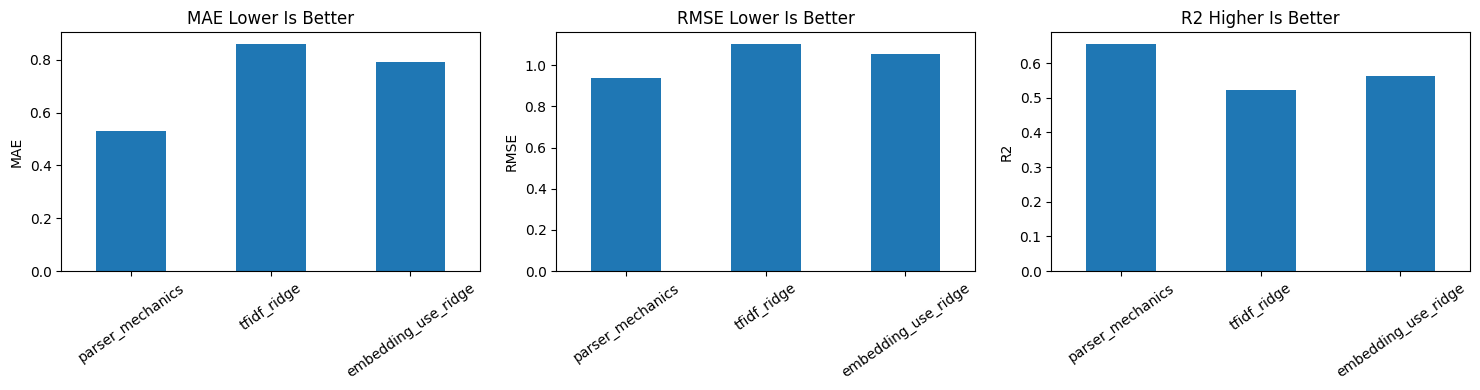

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_df.plot(kind="bar", x="model", y="mae", ax=axes[0], legend=False)
axes[0].set_title("MAE Lower Is Better")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")

metrics_df.plot(kind="bar", x="model", y="rmse", ax=axes[1], legend=False)
axes[1].set_title("RMSE Lower Is Better")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")

metrics_df.plot(kind="bar", x="model", y="r2", ax=axes[2], legend=False)
axes[2].set_title("R2 Higher Is Better")
axes[2].set_xlabel("")
axes[2].set_ylabel("R2")

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

### Residual Analysis

Residuals show where each approach over- or under-predicts `points_minus_pt`. A tighter distribution around zero indicates more consistent predictions, while wider residuals suggest mechanics or card patterns the model is not capturing well.

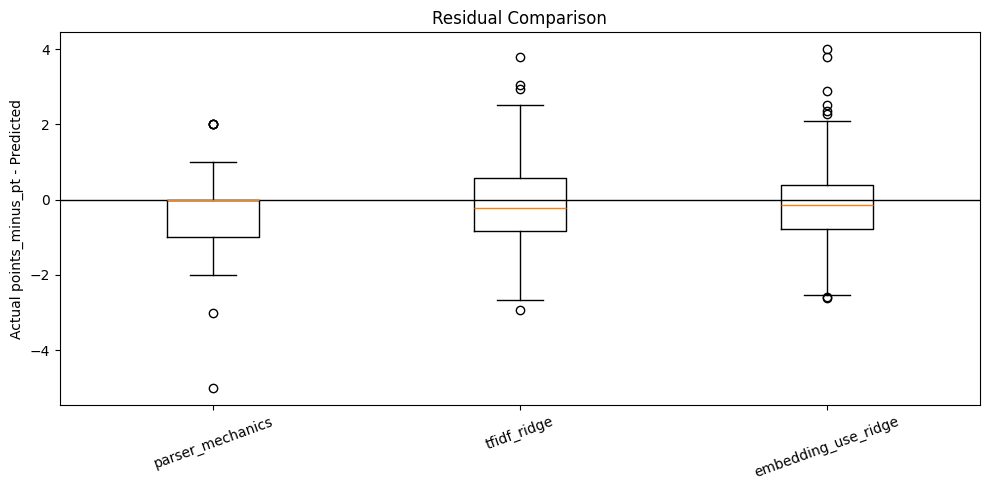

In [21]:
residuals_df = pd.DataFrame({
    "parser_mechanics": parser_test["parser_mechanics_residual"].values,
    "tfidf_ridge": tfidf_results["tfidf_residual"].values,
    "embedding_use_ridge": embedding_results["embedding_residual"].values,
})

plt.figure(figsize=(10, 5))
plt.boxplot(
    [residuals_df[col] for col in residuals_df.columns],
    tick_labels=residuals_df.columns,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Residual Comparison")
plt.ylabel("Actual points_minus_pt - Predicted")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Actual vs Predicted Scores

These plots compare each model's predictions against the true `points_minus_pt` values. Points closer to the diagonal line are better predictions; points far from the line show cases where a model disagrees with the hand-scored labels.

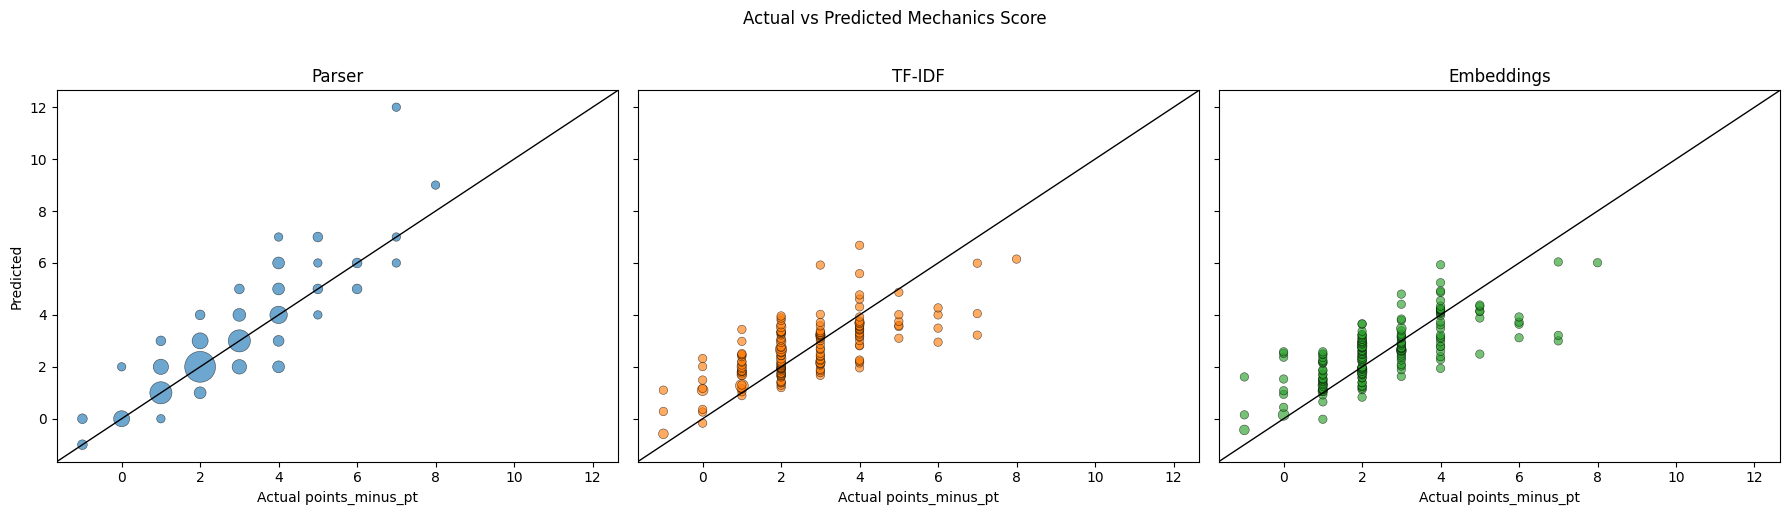

In [22]:
actual = test_df["points_minus_pt"]

model_plots = [
    ("Parser", parser_test["parser_mechanics_score"], "tab:blue"),
    ("TF-IDF", tfidf_preds, "tab:orange"),
    ("Embeddings", embedding_preds, "tab:green"),
]

min_val = min(
    actual.min(),
    parser_test["parser_mechanics_score"].min(),
    tfidf_preds.min(),
    embedding_preds.min(),
)
max_val = max(
    actual.max(),
    parser_test["parser_mechanics_score"].max(),
    tfidf_preds.max(),
    embedding_preds.max(),
)

padding = (max_val - min_val) * 0.05
axis_min = min_val - padding
axis_max = max_val + padding

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, (title, preds, color) in zip(axes, model_plots):
    plot_df = pd.DataFrame({
        "actual": actual.values,
        "predicted": np.asarray(preds),
    })

    # Keep continuous model predictions visually readable while still showing overlap.
    if title != "Parser":
        plot_df["predicted"] = plot_df["predicted"].round(2)

    counts = (
        plot_df
        .groupby(["actual", "predicted"])
        .size()
        .reset_index(name="count")
    )

    ax.scatter(
        counts["actual"],
        counts["predicted"],
        s=25 + counts["count"] * 12,
        alpha=0.65,
        color=color,
        edgecolor="black",
        linewidth=0.4,
    )

    ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual points_minus_pt")
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

axes[0].set_ylabel("Predicted")
fig.suptitle("Actual vs Predicted Mechanics Score", y=1.02)
plt.tight_layout()
plt.show()

Marker size indicates how many cards share the same actual/predicted coordinate. This matters most for the parser because its rule-based scores are discrete, so many cards overlap exactly. The NLP baselines produce continuous predictions, which spread points across more unique coordinates.

### Largest Parser Misses

The parser results are strong overall, but the largest absolute residuals show where the rule-based system still needs work. These are the cards where the parser's mechanics score differs most from the hand-scored `points_minus_pt` value on the shared test set.

We treat these as limitation examples rather than pipeline failures: they can point to missing text patterns, overvalued mechanics, or context that was captured in manual scoring but not yet represented in the feature rules.

In [23]:
parser_test.assign(
    abs_residual=parser_test["parser_mechanics_residual"].abs()
).sort_values("abs_residual", ascending=False)[
    [
        "name",
        "set",
        "points_minus_pt",
        "parser_mechanics_score",
        "parser_mechanics_residual",
    ]
].head(10)

,name,set,points_minus_pt,parser_mechanics_score,parser_mechanics_residual
453,Hooded Hydra,ktk,7.0,12,-5.0
377,Boggart Mob,lrw,4.0,7,-3.0
136,Rotlung Reanimator,ons,5.0,7,-2.0
673,Adaptive Shimmerer,iko,4.0,2,2.0
290,Warren-Scourge Elf,lrw,2.0,4,-2.0
630,Duskfang Mentor,iko,4.0,6,-2.0
544,Thousand Winds,ktk,4.0,2,2.0
615,Frillscare Mentor,iko,4.0,6,-2.0
756,"Helga, Skittish Seer",blb,5.0,7,-2.0
360,Dauntless Dourbark,lrw,0.0,2,-2.0


### Summary

On this dataset, the parser outperforms both TF-IDF and Universal Sentence Encoder baselines. This supports using a rule-based mechanics parser for Magic card text: the language is templated, semi-structured, and tightly tied to formal game rules. The remaining high-residual cases give us concrete directions for future feature and scoring improvements.